# Somatic Hypermutation (SHM) Simulator — Prototype Suite

**Author:** Tahreem Karim  
**Status:** Prototype / work in progress  
**Stack:** Pure Python, no external dependencies (self-contained)

---

## What is this?

Every time your immune system encounters a new pathogen, *B cells evolve antibodies in real time*. Inside our lymph nodes, structures called **germinal centers** run an accelerated Darwinian process. B cells rapidly mutate their antibody genes, compete to bind the pathogen best, and the winners proliferate.

The mutation mechanism driving this is **somatic hypermutation (SHM)**. An enzyme called AID (Activation Induced Cytidine Deaminase) introduces point mutations into antibody variable regions at ~**a million times higher** than the rest of the genome. Crucially, these mutations aren't exactly random. AID preferentially targets specific short DNA sequences called **hotspot motifs** (like RGYW and WRC). 

I created this tool as practice, because it ties together my two degrees in 'Immunology' and 'Data Science'. This (polished) notebook builds shows my thought process, in three stages.


## How this notebook is organized

Each stage builds on the last then supersedes it. A lot of earlier code is kept purely for showing the design evolution. They are not still in use.

| Stage | What's built | Key insight |
|-------|-------------|-----------------|
| **1. Core engine** | Point mutation function + cycle generator | Track where mutations happen |
| **2. Hotspot matching** | IUPAC degenerate motif matcher | AID targets ambiguous sequence contexts, so the code needs to use the IUPAC alphabet |
| **3. Integrated pipeline** | Motif aware mutation engine + `HotspotModel` class | Mutation rates per position, scaled by  motif enrichment and immune cell state |

> The notebook is designed to be read sequentially. If you just want to run the final model, go to Stage 3.


---
## Stage 1 · Core Mutation Engine

The first goal is simple, given a DNA sequence and a mutation rate, produce a plausible mutated version. Then that will be applied repeatedly to simulate cycles of **germinal center division**.

### 1.1 Basic point mutation: v1

*Each base is independently mutated with some probability, always substituting to a different base.* This is the heurestic everything else builds on.


In [1]:
import random

def genDNAptMutationsFX_v1(sequence, mutation_rate):
    """
    Introduce point mutations into a DNA sequence.

    Args:
        sequence (str): DNA sequence string (uppercase A/C/G/T expected)
        mutation_rate (float): per base mutation probability in [0, 1]

    Returns:
        mutated sequence as a string 
    """
    if not (0 <= mutation_rate <= 1):
        raise ValueError("Mutation rate must be between [0, 1]")

    bases = ['A', 'C', 'G', 'T']
    seqList = list(sequence)

    for i, bp in enumerate(seqList):
        if random.random() < mutation_rate:
            seqList[i] = random.choice([b for b in bases if b != bp])

    return ''.join(seqList)


### 1.2 Cycle generator: v1

Germinal center B cells go through repeated rounds of mutation and selection so *the simulator needs to apply mutations cumulatively, not independently each time*. Each cycle inherits the mutations from the previous one, just as daughter cells inherit their parent's sequence.

A **Python generator** yields one cycle at a time without storing all intermediate sequences in memory. For long sequences or many cycles, this greatly decreases computation time.


In [2]:
def shm_generator_v1(sequence, mutation_rate, num_cycles):
    """
    Generator that applies SHM cycle by cycle.

    Yields baseline sequence at cycle 0, then applies mutations
    cumulatively for subsequent cycles simulating clonal descent.

    Args:
        sequence (str): initial germline sequence
        mutation_rate (float): per-base mutation probability per cycle
        num_cycles (int): number of germinal center cycles to simulate

    Yields:
        tuple[int, str]: (cycle_number, mutated_sequence)
    """
    
    if not isinstance(num_cycles, int) or num_cycles < 0:
        raise ValueError("num_cycles must be a positive integer")

    currentSeq = sequence
    yield (0, currentSeq)  # baseline

    for cycle in range(1, num_cycles + 1):
        currentSeq = genDNAptMutationsFX_v1(currentSeq, mutation_rate)
        yield (cycle, currentSeq)


### 1.3 quick sanity check

Does the sequence actually change? Do mutations accumulate across cycles?


In [3]:
gene_sequence = "ATCGATCGATCGATCG" * 10  # 160 bp test sequence
mutation_rate = 0.01   # per base per cycle, elevated for visibility
num_cycles    = 5

print("Basic SHM Generator — v1")
print("=" * 50)
print(f"Sequence length : {len(gene_sequence)} bp")
print(f"Mutation rate   : {mutation_rate} per bp per cycle")
print(f"Cycles          : {num_cycles}\n")

for cycle, seq in shm_generator_v1(gene_sequence, mutation_rate, num_cycles):
    print(f"Cycle {cycle}: {seq[:60]}...")


Basic SHM Generator — v1
Sequence length : 160 bp
Mutation rate   : 0.01 per bp per cycle
Cycles          : 5

Cycle 0: ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG...
Cycle 1: ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG...
Cycle 2: ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG...
Cycle 3: ATCGATCGATCGGTAGATCGTTCGATCGATCGATCGATCGATCGATCGATCGATCGATCG...
Cycle 4: ATCGATCGATCGGTAGATCGTTCGATCGATCGATCGATCGATCGATCGATCGATCGATCG...
Cycle 5: ATCGATCTATCGGTAGATCGTTCGATCGATCGATCTATCGATCGATCGATCGATCGATCG...


### 1.4 Mutation event tracking: v2

The first version throws away the map of *where* mutations happened. That information is essential for analysis like enrichment testing, position frequency matrices, or lineage tracing. I will build that part next.

**Changes from v1:**
- `genDNAptMutationsFX` now returns the mutated sequence and a list of `(position, from_base, to_base)` events
- Positions are 1 based throughout (biology convention is genomic coordinates start at 1)
- `run_SHM_simulation()` collects  full event log and renders a color highlighted sequence for inspection


In [4]:
def genDNAptMutationsFX(sequence, mutation_rate):
    """
    Introduce point mutations and record each event.

    Args:
        sequence (str): DNA sequence (uppercase A/C/G/T)
        mutation_rate (float): per-base mutation probability in [0, 1]

    Returns:
        tuple[str, list[tuple]]:
            - mutated sequence
            - list of (position_1based, from_base, to_base) events
    """
    if not (0 <= mutation_rate <= 1):
        raise ValueError("Mutation rate must be a probability in [0, 1]")

    bases = ['A', 'C', 'G', 'T']
    seq_list = list(sequence)
    mutation_events = []

    for i, bp in enumerate(seq_list):
        if random.random() < mutation_rate:
            new_bp = random.choice([b for b in bases if b != bp])
            seq_list[i] = new_bp
            mutation_events.append((i + 1, bp, new_bp))  # 1-based position

    return ''.join(seq_list), mutation_events


def shm_generator(sequence, mutation_rate=1e-3, num_cycles=10):
    """
    Generator yielding (cycle, sequence, events) tuples.

    Yields:
        tuple[int, str, list]: cycle number, mutated sequence, mutation events
    """
    if not isinstance(num_cycles, int) or num_cycles < 0:
        raise ValueError("num_cycles must be a non-negative integer")

    current_seq = sequence
    yield 0, current_seq, []  # baseline

    for cycle in range(1, num_cycles + 1):
        current_seq, events = genDNAptMutationsFX(current_seq, mutation_rate)
        yield cycle, current_seq, events


def run_SHM_simulation(sequence, mutation_rate=1e-3, num_cycles=10):
    """
    Run SHM simulation and print a summary with color-highlighted mutations.

    Mutated positions are highlighted in the terminal output using ANSI codes.
    (Colors render in Jupyter and most terminals.)

    Returns:
        tuple[str, list, str]: (final_sequence, mutation_log, colored_string)
    """
    original_seq = sequence
    final_seq    = sequence
    mutation_log = []

    for cycle, seq, events in shm_generator(sequence, mutation_rate, num_cycles):
        final_seq = seq
        for pos, old, new in events:
            mutation_log.append((cycle, pos, old, new))

    mutated_positions = {pos for _, pos, _, _ in mutation_log}

    # ANSI highlight: mutated bases in bold magenta
    colored = "".join(
        f"\033[1;95m{b}\033[0m" if (i + 1) in mutated_positions else b
        for i, b in enumerate(final_seq)
    )

    print("\nSomatic Hypermutation Generator — v2")
    print("=" * 50)
    print(f"Sequence length : {len(original_seq)} bp")
    print(f"Mutation rate   : {mutation_rate:.4f} per bp per cycle")
    print(f"Cycles          : {num_cycles}")
    print(f"Total mutations : {len(mutation_log)}")
    print(f"Avg / cycle     : {len(mutation_log) / num_cycles:.2f}")
    print("=" * 50)
    print("Mutation log (cycle | position | substitution):")
    for cycle, pos, old, new in mutation_log:
        print(f"  Cycle {cycle:>2}  |  pos {pos:>3}  |  {old} → {new}")
    print("=" * 50)
    print("Final sequence (mutated positions in magenta):")
    print(colored)

    return final_seq, mutation_log, colored


In [5]:
gene_sequence = "ATGC" * 40   # 160 bp
mutation_rate = 0.001
num_cycles    = 50

run_SHM_simulation(gene_sequence, mutation_rate, num_cycles);
# semicolon suppresses Jupyter's automatic display of the return value



Somatic Hypermutation Generator — v2
Sequence length : 160 bp
Mutation rate   : 0.0010 per bp per cycle
Cycles          : 50
Total mutations : 11
Avg / cycle     : 0.22
Mutation log (cycle | position | substitution):
  Cycle 12  |  pos 110  |  T → C
  Cycle 12  |  pos 140  |  C → G
  Cycle 15  |  pos  90  |  T → A
  Cycle 16  |  pos  61  |  A → G
  Cycle 17  |  pos 106  |  T → A
  Cycle 19  |  pos  46  |  T → C
  Cycle 25  |  pos 119  |  G → A
  Cycle 29  |  pos  92  |  C → T
  Cycle 35  |  pos  94  |  T → A
  Cycle 37  |  pos  77  |  A → C
  Cycle 48  |  pos 108  |  C → G
Final sequence (mutated positions in magenta):
ATGCATGCATGCATGCATGCATGCATGCATGCATGCATGCATGCACGCATGCATGCATGCGTGCATGCATGCATGCCTGCATGCATGCAAGTAAGCATGCATGCAAGGACGCATGCATACATGCATGCATGCATGCATGGATGCATGCATGCATGCATGC


---
## Stage 2 · Hotspot Motif Matching

The core engine treats every position equally but real SHM doesn't.

AID enzyme activity is strongly enriched at specific short sequence contexts. The most commonly studied are:

| Motif | Meaning | Enrichment |
|-------|---------|------------|
| **RGYW** | {A/G} G {C/T} {A/T} | ~2.5× above baseline |
| **WRC** | {A/T} {A/G} C | ~2.0× |
| **GNW** | G {any} {A/T} | ~5.0× — reflects ~92% of observed G mutations |

The letters R, Y, W, N etc. are **IUPAC ambiguity codes**, standard notation in bioinformatics for positions that can be one of several bases. A matcher that only understands A/C/G/T can't find these motifs. We need to build one with the full IUPAC alphabet.

### 2.1 IUPAC degenerate base matcher

The implementation has two paths: 
    - a fast exact-match path when the motif contains no ambiguity codes, and 
    - a full sliding window path when it does - avoids checking exact motifs like `AGCT`.


In [6]:
DEGENERATE_MAP = {
    "A": ["A"], "C": ["C"], "G": ["G"], "T": ["T"],        # exact bases
    "R": ["A", "G"], "Y": ["C", "T"], "W": ["A", "T"],    # puRine, pYrimidine, Weak
    "S": ["G", "C"], "K": ["G", "T"], "M": ["A", "C"],    # Strong, Keto, aMino
    "B": ["C", "G", "T"], "D": ["A", "G", "T"],        # not-A, not-C
    "H": ["A", "C", "T"], "V": ["A", "C", "G"],        # not-G (H), not-T (V)
    "N": ["A", "C", "G", "T"],                           # any
}


def match_hotspot(sequence: str, motif: str) -> list[int]:
    """
    Find all 1 based positions where `motif` = `sequence`.

    Uses an 'exact match fast path' when the motif has no ambiguity codes.

    Args:
        sequence (str): DNA sequence (case insensitive!)
        motif (str): target motif, may include IUPAC codes (case insensitive!)

    Returns:
        list[int]: 1 based start positions of all matches
    """
    sequence = sequence.upper()
    motif    = motif.upper()
    k        = len(motif)

    # Exact string match, no degeneracy
    if all(base in "ACGT" for base in motif):
        return [i + 1 for i in range(len(sequence) - k + 1)
                if sequence[i:i+k] == motif]

    # Sliding window
    matches = []
    for i in range(len(sequence) - k + 1):
        window = sequence[i:i+k]
        if all(window[j] in DEGENERATE_MAP[motif[j]] for j in range(k)):
            matches.append(i + 1)
    return matches


### 2.2 Smoke tests

Does it find what it should? *The controlled test below verifies one positive and one negative case for RGYW.*


In [7]:
test_seq = "AGCTAGCTTACAGAGCT" * 12

print("Exact motif  'AGCT':", match_hotspot(test_seq, "AGCT")[:8], "...")
print("Degenerate   'RGYW':", match_hotspot(test_seq, "RGYW")[:8], "...")


# Controlled case RGYW = {A,G}{G}{C,T}{A,T}
# AGCT → R=A✓ G=G✓ Y=C✓ W=T✓   should match
# AGGT → R=A✓ G=G✓ Y=G✗        should NOT match


controlled = "AGCT AGGT ACTT TGCT".replace(" ", "")
print("\nControlled test:", controlled)
print("  AGCT matches:", match_hotspot(controlled, "AGCT"))   # expect [1]
print("  RGYW matches:", match_hotspot(controlled, "RGYW"))   # expect [1, 6]  bc AGTT also matches: R✓ G✓ Y✓ W✓


Exact motif  'AGCT': [1, 5, 14, 18, 22, 31, 35, 39] ...
Degenerate   'RGYW': [1, 5, 14, 18, 22, 31, 35, 39] ...

Controlled test: AGCTAGGTACTTTGCT
  AGCT matches: [1]
  RGYW matches: [1, 6]


### 2.3 Weighting matches

Finding a hotspot position isn't the end goal. We want to use those positions to *increase local mutation probability in the simulation*. The simplest way is to return a weight alongside each match position, which the mutation engine will use as a multiplier.


In [8]:
HOTSPOT_WEIGHTS = {
    "neutral":    1.0,   # default, no motif 
    "WRC":        2.0,   # Rogozin et al. / Shapiro et al.
    "GYW":        2.0,
    "RGYW":       2.5,   # classic AID hotspot (WRC complement)
    "WRCH":       1.6,
    "GNW":        5.0,   # high enrichment! (~92% G→ mutations)
    "coldspot":   0.5,
}


def match_hotspot_weighted(sequence: str, motif: str,
                           use_weights: bool = False):
    """
    Match `motif` in `sequence`, optionally returning per position weights.

    Args:
        sequence (str): DNA sequence
        motif (str): IUPAC motif
        use_weights (bool): if True, returns (position, weight) tuples;
                            if False, returns plain position list

    Returns:
        list[int] | list[tuple[int, float]]: positions or (position, weight)
    """
    positions = match_hotspot(sequence, motif)

    if not use_weights:
        return positions

    weight = HOTSPOT_WEIGHTS.get(motif, HOTSPOT_WEIGHTS["neutral"])
    return [(pos, weight) for pos in positions]


In [9]:
seq = "AGCTAGGTAGTTTAGCT"

print("-- No weights --")
print("AGCT:", match_hotspot_weighted(seq, "AGCT"))
print("RGYW:", match_hotspot_weighted(seq, "RGYW"))

print("\n-- With weights --")
print("AGCT:", match_hotspot_weighted(seq, "AGCT", use_weights=True))
print("RGYW:", match_hotspot_weighted(seq, "RGYW", use_weights=True))


-- No weights --
AGCT: [1, 14]
RGYW: [1, 6, 9, 14]

-- With weights --
AGCT: [(1, 1.0), (14, 1.0)]
RGYW: [(1, 2.5), (6, 2.5), (9, 2.5), (14, 2.5)]


### 2.4 Refactoring into a class

Now there are several related pieces floating around as global variables: the degenerate map, the weight dict, the immune state. Bundling them into a class makes everything easy to instantiate different models side by side (e.g., germinal center vs. memory B cell) without risk of them **sharing state**.

The class also gets an `explain()` method, the literature source for each weight, useful for debugging and citation.


In [10]:
class HotspotModel:
    """
    Motif-aware SHM hotspot model.

    Encapsulates IUPAC degenerate matching, per-motif enrichment weights,
    and immune-state scaling into a single reusable object.

    Args:
        state (str): immune context — one of 'naive', 'germinal_center', 'memory'
        weights (dict, optional): override default motif weights

    Example:
        model = HotspotModel(state="germinal_center")
        hits  = model.find("AGCTAGGT", "RGYW", use_weights=True)
    """

    # Default hotspot weights from literature
    DEFAULT_WEIGHTS = {
        "neutral":  1.0,
        "WRC":      2.0,   # Rogozin & Diaz (2004); Shapiro et al. (2002)
        "GYW":      2.0,   # reverse complement of WRC
        "RGYW":     2.5,   # canonical AID hotspot
        "WRCH":     1.6,
        "GNW":      5.0,   # ~92% G-mutation enrichment in this context
        "coldspot": 0.5,
    }

    # Immune state scaling 
    STATE_SCALING = {
        "naive":            0.2,   # minimal SHM activity
        "germinal_center":  1.0,   # peak AID expression, full SHM
        "memory":           1.8,   # accumulated mutations in long lived clones
    }

    # IUPAC degenerate base map 
    DEGENERATE_MAP = {
        "A": ["A"], "C": ["C"], "G": ["G"], "T": ["T"],
        "R": ["A", "G"], "Y": ["C", "T"], "W": ["A", "T"],
        "S": ["G", "C"], "K": ["G", "T"], "M": ["A", "C"],
        "B": ["C", "G", "T"], "D": ["A", "G", "T"],
        "H": ["A", "C", "T"], "V": ["A", "C", "G"],
        "N": ["A", "C", "G", "T"],
    }

    def __init__(self, state: str = "germinal_center", weights: dict = None):
        if state not in self.STATE_SCALING:
            raise ValueError(f"Unknown state '{state}'. "
                             f"Choose from: {list(self.STATE_SCALING)}")
        self.state   = state
        self.weights = {**self.DEFAULT_WEIGHTS, **(weights or {})}

    
    # Matching engine
    def _match_exact(self, seq: str, motif: str) -> list[int]:
        k = len(motif)
        return [i + 1 for i in range(len(seq) - k + 1)
                if seq[i:i+k] == motif]

    def match_degenerate(self, seq: str, motif: str) -> list[int]:
        """Return 1-based positions where motif matches seq (IUPAC-aware)."""
        seq, motif = seq.upper(), motif.upper()
        if all(b in "ACGT" for b in motif):
            return self._match_exact(seq, motif)
        k = len(motif)
        return [i + 1 for i in range(len(seq) - k + 1)
                if all(seq[i+j] in self.DEGENERATE_MAP[motif[j]] for j in range(k))]

    
    # Weight engine 
    def apply_weights(self, positions: list[int], motif: str) -> list[tuple]:
        """Map positions to (position, effective_weight) tuples."""
        base_w   = self.weights.get(motif, self.weights["neutral"])
        scaling  = self.STATE_SCALING[self.state]
        eff_w    = base_w * scaling
        return [(pos, eff_w) for pos in positions]

    
    # Public API 
    def find(self, seq: str, motif: str,
             use_weights: bool = False) -> list:
        """
        Find all occurrences of `motif` in `seq`.

        Args:
            seq (str): DNA sequence
            motif (str): IUPAC motif string
            use_weights (bool): if True, return (position, weight) tuples

        Returns:
            list[int] | list[tuple[int, float]]
        """
        hits = self.match_degenerate(seq, motif)
        return self.apply_weights(hits, motif) if use_weights else hits

        
    def get_position_weights(self, seq: str) -> dict[int, float]:
        """
        Scan all configured motifs and return a per-position weight map.

        Used by the mutation engine to scale local mutation rates.

        Returns:
            dict[int, float]: {1-based_position: max_weight_across_motifs}
        """
        scaling    = self.STATE_SCALING[self.state]
        pos_weights = {}
        for motif, w in self.weights.items():
            if motif in ("neutral", "coldspot"):
                continue
            for pos in self.match_degenerate(seq, motif):
                # take the maximum weight if a position is covered by multiple motifs
                current = pos_weights.get(pos, 0)
                pos_weights[pos] = max(current, w * scaling)
        return pos_weights

    
    def explain(self, motif: str) -> dict:
        """Return weight metadata for a motif (useful for debugging/citation)."""
        return {
            "motif":            motif,
            "weight":           self.weights.get(motif, None),
            "state_scaling":    self.STATE_SCALING.get(self.state),
            "effective_weight": (self.weights.get(motif, 1.0)
                                 * self.STATE_SCALING.get(self.state, 1.0)),
        }


### 2.5 Functional tests

Check that weights and immune state scaling mechanisms behave correctly. Memory B cells (state scaling 1.8×) should return higher effective weights than germinal center cells (1.0×).


In [11]:
model_gc = HotspotModel(state="germinal_center")
model_mem = HotspotModel(state="memory")

test_seq = "AGCTAGGTAGTTTAGCT"

print("find() — no weights:")
print(" ", model_gc.find(test_seq, "RGYW"))

print("\nfind() — with weights (germinal center):")
print(" ", model_gc.find(test_seq, "RGYW", use_weights=True))

print("\nfind() — with weights (memory, 1.8× scaling):")
print(" ", model_mem.find(test_seq, "RGYW", use_weights=True))

print("\nexplain() — germinal center:")
print(" ", model_gc.explain("RGYW"))


find() — no weights:
  [1, 6, 9, 14]

find() — with weights (germinal center):
  [(1, 2.5), (6, 2.5), (9, 2.5), (14, 2.5)]

find() — with weights (memory, 1.8× scaling):
  [(1, 4.5), (6, 4.5), (9, 4.5), (14, 4.5)]

explain() — germinal center:
  {'motif': 'RGYW', 'weight': 2.5, 'state_scaling': 1.0, 'effective_weight': 2.5}


### 2.6 Performance at scale

The degenerate matcher runs a sliding window over the sequence, so it's O(n × k) where n is sequence length and k is motif length. On a 100k bp sequence this should still be fast enough for interactive use.


In [12]:
# 100k bp stress test, linear time behaviour?
seq_100k = "AGGT" * 25_000  # 100,000 bp

%time hits = model_gc.find(seq_100k, "RGYW")
print(f"Matches in 100k bp: {len(hits)}")


CPU times: user 148 ms, sys: 0 ns, total: 148 ms
Wall time: 148 ms
Matches in 100k bp: 24999


### 2.7 Edge cases

Sequences from real datasets contain lowercase bases, gap characters (`-`), or segments of 'NNN...' and the matcher should handle all of these.


In [13]:
print("Lowercase input:   ", model_gc.find("acgtacgtacgt", "RGYW"))
print("Gapped sequence:   ", model_gc.find("AGCT---AGCT", "AGCT"))
print("N-only sequence:   ", model_gc.find("NNNNNNNN", "RGYW"))
print("No matches:        ", model_gc.find("TTTTTTTTT", "RGYW"))


Lowercase input:    []
Gapped sequence:    [1, 8]
N-only sequence:    []
No matches:         []


---
## Stage 3 · Integrated Motif-Aware Pipeline

Stages 1 and 2 are now combined into a single engine. The key difference from Stage 1: before sampling each base for mutation, we look up whether that position falls inside a hotspot motif. If it does, the effective mutation rate is scaled up accordingly.

```
effective_rate(pos) = base_rate × hotspot_weight(pos) × state_scaling
```

For a germinal-center B cell (`state_scaling = 1.0`) at an RGYW site (`weight = 2.5`), a base rate of 0.001 becomes an effective rate of 0.0025 at that position — 2.5× more likely to mutate than a non-hotspot base.

The model ships with **hardcoded default weights** drawn from the literature, so it runs with no external config files. A YAML loader is stubbed in the `DEFAULT_CONFIG` dict for future experiment-specific tuning.


In [14]:
import random

# ── Self-contained default config (no external files required) ────────────────
# To use a custom YAML, pass config_path to HotspotModel.__init__() when that
# feature is implemented. The structure mirrors hotspot_weights_human.yaml:
#
#   RGYW:
#     value: 2.5
#     source: "Rogozin & Diaz (2004) J Immunol"
#
DEFAULT_CONFIG = {
    "neutral":  {"value": 1.0,  "source": "baseline — no motif context"},
    "WRC":      {"value": 2.0,  "source": "Rogozin & Diaz (2004)"},
    "GYW":      {"value": 2.0,  "source": "Rogozin & Diaz (2004) — WRC complement"},
    "RGYW":     {"value": 2.5,  "source": "Shapiro et al. (2002); Rogozin & Diaz (2004)"},
    "WRCH":     {"value": 1.6,  "source": "Pham et al. (2003)"},
    "GNW":      {"value": 5.0,  "source": "~92% G-mutation enrichment; Dorner et al. (1998)"},
    "coldspot": {"value": 0.5,  "source": "SYC / GRS cold motifs — Rogozin & Diaz (2004)"},
}


class HotspotModel:
    """
    Motif aware SHM hotspot model, integrated pipeline version.

    Extends the Stage 2 class with:
    - Hardcoded default config (fully self-contained, no external files)
    - Optional YAML config loading (stub; enable when needed)
    - Citation recall via explain()

    Args:
        state (str): 'naive' | 'germinal_center' | 'memory'
        config (dict, optional): custom weight config dict (mirrors DEFAULT_CONFIG)
    """

    STATE_SCALING = {
        "naive":            0.2,
        "germinal_center":  1.0,
        "memory":           1.8,
    }

    DEGENERATE_MAP = {
        "A": ["A"], "C": ["C"], "G": ["G"], "T": ["T"],
        "R": ["A", "G"], "Y": ["C", "T"], "W": ["A", "T"],
        "S": ["G", "C"], "K": ["G", "T"], "M": ["A", "C"],
        "B": ["C", "G", "T"], "D": ["A", "G", "T"],
        "H": ["A", "C", "T"], "V": ["A", "C", "G"],
        "N": ["A", "C", "G", "T"],
    }

    def __init__(self, state: str = "germinal_center", config: dict = None):
        if state not in self.STATE_SCALING:
            raise ValueError(f"Unknown state '{state}'. "
                             f"Choose from: {list(self.STATE_SCALING)}")
        self.state   = state
        cfg          = config or DEFAULT_CONFIG
        self.weights = {k: v["value"]  for k, v in cfg.items()}
        self.sources = {k: v["source"] for k, v in cfg.items()}

    
    # Internals 
    def _match(self, seq: str, motif: str) -> list[int]:
        seq, motif = seq.upper(), motif.upper()
        k = len(motif)
        if all(b in "ACGT" for b in motif):
            return [i + 1 for i in range(len(seq) - k + 1)
                    if seq[i:i+k] == motif]
        return [i + 1 for i in range(len(seq) - k + 1)
                if all(seq[i+j] in self.DEGENERATE_MAP[motif[j]] for j in range(k))]

    
    # Public API
    def find(self, seq: str, motif: str, use_weights: bool = False) -> list:
        hits    = self._match(seq, motif)
        if not use_weights:
            return hits
        w = self.weights.get(motif, self.weights["neutral"]) * self.STATE_SCALING[self.state]
        return [(pos, w) for pos in hits]

    def get_position_weights(self, seq: str) -> dict[int, float]:
        """
        Skips 'neutral' and 'coldspot' (handled separately in mutation engine).
        """
        scaling    = self.STATE_SCALING[self.state]
        pos_map    = {}
        skip       = {"neutral", "coldspot"}
        for motif, w in self.weights.items():
            if motif in skip:
                continue
            for pos in self._match(seq, motif):
                pos_map[pos] = max(pos_map.get(pos, 0), w * scaling)
        return pos_map

    def explain(self, motif: str) -> dict:
        return {
            "motif":            motif,
            "weight":           self.weights.get(motif),
            "source":           self.sources.get(motif, "No citation available"),
            "state":            self.state,
            "state_scaling":    self.STATE_SCALING.get(self.state),
            "effective_weight": (self.weights.get(motif, 1.0)
                                 * self.STATE_SCALING.get(self.state, 1.0)),
        }


# Motif aware point mutation engine 
def mutate_sequence(sequence: str, base_rate: float,
                    hotspot_model: HotspotModel = None) -> tuple[str, list]:
    """
    Apply one round of SHM to a sequence.

    Local mutation rate is scaled by hotspot weights when a model is provided:
        effective_rate = base_rate × position_weight  (capped at 1.0)

    Args:
        sequence (str): input DNA sequence
        base_rate (float): baseline per-base mutation probability
        hotspot_model (HotspotModel, optional): if None, uniform mutation

    Returns:
        tuple[str, list[tuple]]:
            - mutated sequence
            - list of (position_1based, from_base, to_base) events
    """
    bases         = ['A', 'C', 'G', 'T']
    seq_list      = list(sequence)
    events        = []
    pos_weights   = hotspot_model.get_position_weights(sequence) if hotspot_model else {}

    for i, bp in enumerate(seq_list):
        rate = base_rate
        pos  = i + 1
        if pos in pos_weights:
            rate = min(base_rate * pos_weights[pos], 1.0)  # cap at 100%

        if random.random() < rate:
            new_bp = random.choice([b for b in bases if b != bp])
            seq_list[i] = new_bp
            events.append((pos, bp, new_bp))

    return ''.join(seq_list), events


# Cycle generator 

def shm_generator(sequence: str, base_rate: float = 1e-3,
                  num_cycles: int = 10,
                  hotspot_model: HotspotModel = None):
    """
    Yield (cycle, sequence, events) for each SHM cycle.

    cycle=0 yields the unmutated baseline.
    """
    current = sequence
    yield 0, current, []
    for c in range(1, num_cycles + 1):
        current, ev = mutate_sequence(current, base_rate, hotspot_model)
        yield c, current, ev



# Full simulation run
def run_SHM_simulation(sequence: str, base_rate: float = 1e-3,
                       num_cycles: int = 10,
                       model: HotspotModel = None) -> tuple:
    
    """
    Args:
        sequence (str): germline input sequence
        base_rate (float): baseline per-base mutation rate
        num_cycles (int): number of SHM cycles
        model (HotspotModel, optional): hotspot model; None = uniform rates

    Returns:
        tuple[str, list, str]:
            final_sequence, mutation_log, ansi_colored_string
    """

    
    final_seq = sequence
    log       = []

    for cycle, seq, events in shm_generator(sequence, base_rate, num_cycles, model):
        final_seq = seq
        for pos, old, new in events:
            log.append((cycle, pos, old, new))

    mutated_pos = {p for _, p, _, _ in log}
    colored     = "".join(
        f"\033[1;95m{b}\033[0m" if (i + 1) in mutated_pos else b
        for i, b in enumerate(final_seq)
    )

    print("\nSomatic Hypermutation Simulator — Motif Aware Pipeline")
    print("=" * 60)
    print(f"Sequence length : {len(sequence)} bp")
    print(f"Base rate       : {base_rate}")
    print(f"Cycles          : {num_cycles}")
    print(f"Immune state    : {model.state if model else 'N/A (uniform)'}")
    print(f"Total mutations : {len(log)}")
    print(f"Positions altered: {len(mutated_pos)} / {len(sequence)} "
          f"({100 * len(mutated_pos) / len(sequence):.1f}%)")
    print("=" * 60)
    print("Mutation log:")
    for c, p, o, n in log:
        print(f"  Cycle {c:>2} | pos {p:>4} | {o} → {n}")
    print("=" * 60)
    print("Final sequence (mutated positions in magenta):")
    print(colored)

    return final_seq, log, colored


### 3.1 Full pipeline run

The test sequence below contains several RGYW matching substrings (`AGCT`, `AGTT`). Hotspot enrichment should be visible in mutation log.


In [15]:
model = HotspotModel(state="germinal_center")

seq = "ATGGCTAGCTAGCTAGCTATGCTAGCTATCGATCGATCG" * 4  # 156 bp

final, log, vis = run_SHM_simulation(
    seq, base_rate=0.01, num_cycles=15, model=model
)



Somatic Hypermutation Simulator — Motif Aware Pipeline
Sequence length : 156 bp
Base rate       : 0.01
Cycles          : 15
Immune state    : germinal_center
Total mutations : 44
Positions altered: 40 / 156 (25.6%)
Mutation log:
  Cycle  1 | pos  143 | C → G
  Cycle  2 | pos   53 | T → G
  Cycle  2 | pos   86 | G → C
  Cycle  2 | pos   98 | T → C
  Cycle  2 | pos  102 | A → T
  Cycle  3 | pos   39 | G → A
  Cycle  3 | pos   62 | T → A
  Cycle  3 | pos   64 | G → C
  Cycle  3 | pos   93 | A → T
  Cycle  3 | pos  100 | C → A
  Cycle  3 | pos  115 | T → C
  Cycle  5 | pos    8 | G → T
  Cycle  5 | pos   16 | G → C
  Cycle  5 | pos  142 | G → A
  Cycle  6 | pos   12 | G → C
  Cycle  6 | pos   87 | C → T
  Cycle  6 | pos  102 | T → C
  Cycle  6 | pos  137 | T → A
  Cycle  7 | pos   61 | C → T
  Cycle  8 | pos  123 | T → G
  Cycle  8 | pos  133 | G → A
  Cycle  9 | pos  117 | G → C
  Cycle  9 | pos  141 | A → T
  Cycle 10 | pos   74 | G → T
  Cycle 10 | pos  134 | C → G
  Cycle 11 | pos   4

### 3.2 Visualizing hotspot enrichment

The two panel figure below puts the model's predictions next to what actually happened in the simulation. *If the motif aware engine is working correctly, the peaks in observed mutation counts (top) should correlate with the high pressure positions in the hotspot profile (bottom).*


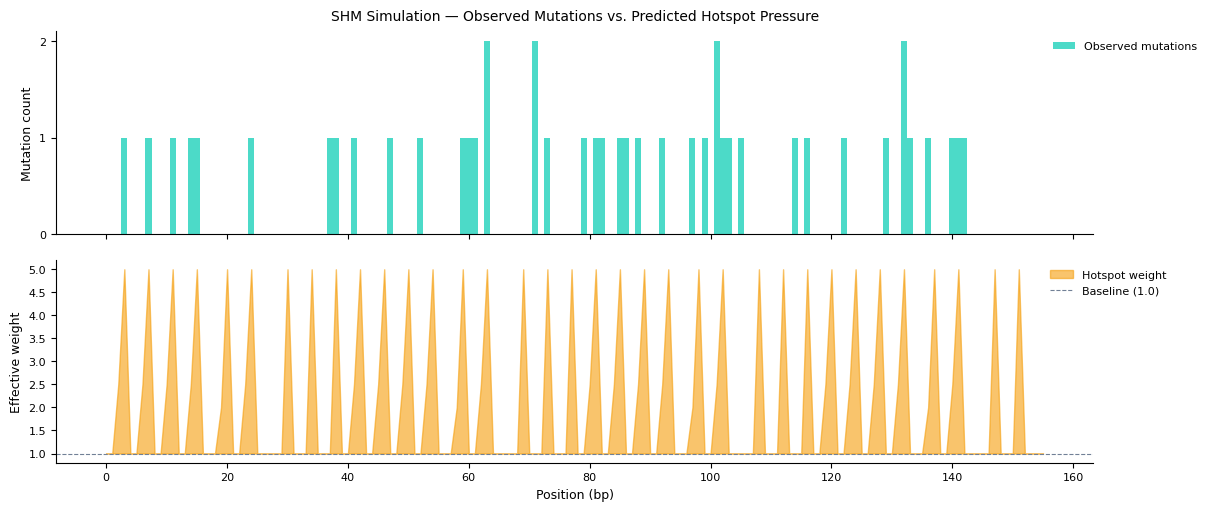

Plot saved to shm_pressure_plot.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

# Build 'per position' mutation count from log 
seq_len    = len(seq)
mut_counts = [0] * seq_len
for _, pos, _, _ in log:
    mut_counts[pos - 1] += 1  # convert to 0-based index


# Hotspot pressure profiles
pos_weights = model.get_position_weights(seq)
pressure    = [pos_weights.get(i + 1, 1.0) for i in range(seq_len)]


# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={"hspace": 0.08},
                         constrained_layout=True)


# Top: observed mutations
axes[0].bar(range(seq_len), mut_counts, color="#2dd4bf", width=1.0,
            alpha=0.85, label="Observed mutations")
axes[0].set_ylabel("Mutation count", fontsize=9)
axes[0].set_title("SHM Simulation — Observed Mutations vs. Predicted Hotspot Pressure",
                  fontsize=10, pad=8)
axes[0].legend(fontsize=8, frameon=False, bbox_to_anchor=(1.11, 1.0), loc='upper right')
axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))



# Bottom: hotspot pressure
axes[1].fill_between(range(seq_len), pressure, 1.0,
                     color="#f59e0b", alpha=0.6, label="Hotspot weight")
axes[1].axhline(1.0, color="#718096", lw=0.8, ls="--", label="Baseline (1.0)")
axes[1].set_ylabel("Effective weight", fontsize=9)
axes[1].set_xlabel("Position (bp)", fontsize=9)
axes[1].legend(fontsize=8, frameon=False, bbox_to_anchor=(1.08, 1.0), loc='upper right')

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

plt.savefig("shm_pressure_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to shm_pressure_plot.png")


## What's next

This prototype is just the stochastic core. A few things are out of scope but are on the roadmap:

- **Transition bias** — AID specifically deaminates cytosine → uracil, which means C→T and G→A transitions should dominate the mutation spectrum. Right now substitutions are drawn uniformly from the other three bases, which is biologically inaccurate.
- **YAML config loading** — swap in organism specific or calibrated weight profiles without coding. The `DEFAULT_CONFIG` structure mirrors the target format.
- **Sequence pre processor** — a cleaning step upstream to normalize case, strip gaps, and flag non IUPAC characters before they reach the engine.
- **Clonal lineage simulation** — extend from a single sequence to a branching tree of B-cell clones, with selection pressure modeled on CDR (antigen binding) vs. FWR (structural) regions.
- **Validation** — compare simulated mutation spectra against published BCR repertoire datasets from IMGT or OGRDB to test whether the model's enrichment pattern matches real SHM data.
